<a href="https://colab.research.google.com/github/HermitSage/Predicting-Adolescent-Depression-using-School-Performance-and-Socio-Demographic-Data-A-ML-Approach/blob/main/7050CEM_final_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path ="/content/drive/MyDrive/MSc Data Science/7050CEM-Project/"

******###### DATA PREPARATION #####*******


*   In this section the files *mcs7_cm_interview, mcs7_cm_derived, mcs7_family_derived, and mcs7_qualifications* are preprocessing and relevant variables for our project are extracted.








Extraction of relevant variables from the files:
*   mcs7_cm_interview,
*   mcs7_family_derived,
*   mcs7_cm_derived
*   mcs7_cm_qualifications







*   MCSID: Cohort Family ID
*   GCNUM00: cohort number in the family.
*   GCEDUC00: Are you going to school/College
*   GCCLSI00: Physical or Mental Illness in last 12 months
*   GCGNID00: Gender (1:Male, 2:Female, 3:Other, 4:Adrogynous, 5:Gender fluid, 6: Non binary)
*   GCSXID00: Sex orientation
  



















In [ ]:
####### Dataframe from mcs7_cm_interview ##########################

## Variables to extract from the mcs7_cm_interview file

cols_cm = ["MCSID", "GCNUM00", "GCEDUC00","GCCLSI00","GCGNID00", "GCSXID00"]

cm_interview = pd.read_csv(path+"mcs7_cm_interview.tab", sep='\t', usecols=cols_cm)
cm_interview.shape



(10343, 6)

The variable GCNUM00 represents the Cohort Member number in the family MCSID.
For simplicity we will use only the Cohort Member GCNUM00=1

In [ ]:
# Keep only the Cohort Member GCNUM00 = 1
cm_interview = cm_interview[cm_interview["GCNUM00"]==1]

#Drop the column GCNUM00
cm_interview.drop(columns=["GCNUM00"], inplace=True)
print("Remaining samples after cleansing of 'GCNUM00':", cm_interview.shape[0])

Remaining samples after cleansing of 'GCNUM00': 10236


In [ ]:
# Handling of missing values

# 1. Reformatting of missing values
# 3: Don't know, 4:Do not wish to answer, 5:Refusal
cm_interview[["GCEDUC00", "GCCLSI00"]] = \
    cm_interview[["GCEDUC00", "GCCLSI00"]].replace([3,4,5], np.nan)
# -9:Prefer not to say/Refusal, -8:Don't know, -1:Not applicable, 7: Irrelevant
cm_interview["GCGNID00"] = cm_interview["GCGNID00"].replace([-9,-8,-1,7], np.nan)
# -1: Not applicable, 7:Do not know, 8:Prefer not to say
cm_interview["GCSXID00"] = cm_interview["GCSXID00"].replace([-1,7,8], np.nan)

# 2. Drop missing values or variables
cm_interview.isna().sum()
cm_interview.dropna(inplace=True)
cm_interview.isna().sum()

,0
MCSID,0
GCEDUC00,0
GCCLSI00,0
GCSXID00,0
GCGNID00,0


In [ ]:
cm_interview.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9651 entries, 0 to 10342
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MCSID     9651 non-null   object 
 1   GCEDUC00  9651 non-null   float64
 2   GCCLSI00  9651 non-null   float64
 3   GCSXID00  9651 non-null   float64
 4   GCGNID00  9651 non-null   float64
dtypes: float64(4), object(1)
memory usage: 452.4+ KB


**File: mcs7_family_derived**



*   MCSID: Chohort Id
*   GDHTYP00 : parents structure
*   GDTOTP00: Number of people in the family (including cohort)






In [ ]:
####### Dataframe from mcs7_family_derived #########################,#

# Variables to extract from the mcs7_family_derived file
cols_fam_der =["MCSID", "GDHTYP00","GDTOTP00"]

family_derived = pd.read_csv(path+"mcs7_family_derived.tab", sep='\t', usecols=cols_fam_der)
family_derived.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10830 entries, 0 to 10829
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   MCSID     10830 non-null  object
 1   GDHTYP00  10830 non-null  int64 
 2   GDTOTP00  10830 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 254.0+ KB


In [ ]:
# Handling of missing values

# 1. Reformatting of missing values
# -1: missing
family_derived["GDHTYP00"] = family_derived["GDHTYP00"].replace(-1, np.nan)
# -2:Do not know
family_derived["GDTOTP00"] = family_derived["GDTOTP00"].replace(-2, np.nan)


# 2. Drop missing values or variables
print(family_derived.isna().sum())
family_derived.dropna(inplace=True)


MCSID         0
GDHTYP00    441
GDTOTP00      0
dtype: int64


In [ ]:
family_derived.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10389 entries, 0 to 10829
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MCSID     10389 non-null  object 
 1   GDHTYP00  10389 non-null  float64
 2   GDTOTP00  10389 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 324.7+ KB




---


**File: mcs7_cm_derived**


---





*   MCSID: Cohort Id
*   GCNUM00: Cohort number in the family
*   GCMCS7AG: Age of the Cohort
*   GCUK90O7: Weight status
*   GDCKESSL: K6 score

In [ ]:
####### Dataframe from mcs7_cm_derived ##########################

# cm_derived: data relating to depression: mcs7_cm_derived
cols_cm_der = ["MCSID","GCNUM00", "GCMCS7AG", "GCUK90O7", "GDCKESSL"]

cm_derived = pd.read_csv(path+"mcs7_cm_derived.tab", sep='\t', usecols=cols_cm_der)
cm_derived.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10948 entries, 0 to 10947
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MCSID     10948 non-null  object 
 1   GCNUM00   10948 non-null  int64  
 2   GCMCS7AG  10948 non-null  float64
 3   GCUK90O7  10948 non-null  int64  
 4   GDCKESSL  10948 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 427.8+ KB


In [ ]:
# Choose only GCNUM00 =1
cm_derived = cm_derived[cm_derived["GCNUM00"]==1]
cm_derived.drop(columns=["GCNUM00"], inplace=True)
cm_derived.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10827 entries, 0 to 10947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MCSID     10827 non-null  object 
 1   GCMCS7AG  10827 non-null  float64
 2   GCUK90O7  10827 non-null  int64  
 3   GDCKESSL  10827 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 422.9+ KB


In [ ]:
# Handling of missing values

# 1. Reformatting of missing values
# -1:Missing/ Not applicable
cm_derived[["GCMCS7AG", "GCUK90O7"]] = \
   cm_derived[["GCMCS7AG", "GCUK90O7"]].replace(-1, np.nan)
# -9:Refusal, -8:Don't know, -1:Not applicable
cm_derived['GDCKESSL'] = cm_derived['GDCKESSL'].replace([-9,-8,-1], np.nan)


# 2. Drop missing values or variables
print(cm_derived.isna().sum())
cm_derived.dropna(inplace=True)

MCSID          0
GCMCS7AG     218
GCUK90O7    1505
GDCKESSL     842
dtype: int64


In [ ]:
cm_derived.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9257 entries, 0 to 10947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MCSID     9257 non-null   object 
 1   GCMCS7AG  9257 non-null   float64
 2   GCUK90O7  9257 non-null   float64
 3   GDCKESSL  9257 non-null   float64
dtypes: float64(3), object(1)
memory usage: 361.6+ KB


**File: mcs7_cm_qualifications**

---
We are only concerned with the ranking grades obtained on GCSE/National Five


*   MCSID: Cohort Id
*   GCNUM00: Cohort number in the family
*   GC_L_GCGD: GCSE Subject Grade (En, Wa, NI)
*   GC_L_FVGD: N5 Subject grade (Scot)
*   GC_S_QUAL_GCSN_R20: Total GCSEs obtained (En, Wa, NI)
*   GC_S_QUAL_NFIR_R20: Total N5s obtained (Scot)


In [ ]:
####### Dataframe from mcs7_cm_qualifications ##########################

# Variables related to school performance: mcs7_cm_qualifications
cols_qualif =['MCSID', 'GCNUM00', 'GC_L_GCGD', 'GC_L_FVGD', "GC_S_QUAL_GCSN_R20", "GC_S_QUAL_NFIR_R20" ]

cm_qualifications = pd.read_csv(path+'mcs7_cm_qualifications.tab', sep='\t', usecols=cols_qualif)
cm_qualifications.shape

(199500, 6)

In [ ]:
# Drop all rows where GCNUM00 = 2
# we are only taking the Cohort Member GCNUM00=1 per family
cm_qualifications = cm_qualifications[cm_qualifications["GCNUM00"] == 1]
cm_qualifications.drop(columns=["GCNUM00"], inplace=True)
cm_qualifications.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197460 entries, 0 to 199499
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   MCSID               197460 non-null  object
 1   GC_S_QUAL_GCSN_R20  197460 non-null  int64 
 2   GC_S_QUAL_NFIR_R20  197460 non-null  int64 
 3   GC_L_GCGD           197460 non-null  int64 
 4   GC_L_FVGD           197460 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 9.0+ MB


In [ ]:
#### FEATURE ENGINEERING OF QUALIFICATION VARIABLES #####################

# ------------- A_Grades features engineering --------------

# Clean grade columns and keep rows with at least one grade
cm_qualifications[["GC_L_GCGD", "GC_L_FVGD"]] = (
    cm_qualifications[["GC_L_GCGD", "GC_L_FVGD"]].replace(-1, np.nan)
)
cm_qualifications = cm_qualifications.dropna(
    subset=["GC_L_GCGD", "GC_L_FVGD"], how="all"
)

# Create A_Grades (take A and A* from Eng, Wal,NI and A from Scot)
cm_qualifications["A_Grades"] = (
    cm_qualifications["GC_L_GCGD"].isin([12, 11, 9, 8, 7]) |
    (cm_qualifications["GC_L_FVGD"] == 1)
).groupby(cm_qualifications["MCSID"]).transform("sum")

# Keep only the first occurence of MCSID and drop variables used for creation
cm_qualifications = (
    cm_qualifications
    .drop(columns=["GC_L_GCGD", "GC_L_FVGD"])
    .drop_duplicates(subset="MCSID")
)
#  Convert dtype to int if not
cm_qualifications["A_Grades"] = cm_qualifications["A_Grades"].astype(int)

# ------------ Total_GCSE_N5 feature engineering ------------

# Combine GCSE and N5 counts to Total_GCSE_N5
missing_codes = [-1, -8, -9]

cm_qualifications[["GC_S_QUAL_GCSN_R20", "GC_S_QUAL_NFIR_R20"]] = (
    cm_qualifications[["GC_S_QUAL_GCSN_R20", "GC_S_QUAL_NFIR_R20"]]
    .replace(missing_codes, np.nan)
)

cm_qualifications["Total_GCSE_N5"] = (
    cm_qualifications["GC_S_QUAL_GCSN_R20"]
    .fillna(cm_qualifications["GC_S_QUAL_NFIR_R20"])
)

cm_qualifications = cm_qualifications.drop(columns=[
    "GC_S_QUAL_GCSN_R20", "GC_S_QUAL_NFIR_R20"
])

cm_qualifications = cm_qualifications.dropna(subset=["Total_GCSE_N5"])

cm_qualifications.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9315 entries, 0 to 199480
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MCSID          9315 non-null   object 
 1   A_Grades       9315 non-null   int64  
 2   Total_GCSE_N5  9315 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 291.1+ KB


In [ ]:
# Combine the three dataframes in one using MCSID
final_data = pd.merge(cm_interview, family_derived, on="MCSID")
final_data = pd.merge(final_data, cm_derived, on="MCSID")
final_data = pd.merge(final_data, cm_qualifications, on="MCSID")
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8549 entries, 0 to 8548
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MCSID          8549 non-null   object 
 1   GCEDUC00       8549 non-null   float64
 2   GCCLSI00       8549 non-null   float64
 3   GCSXID00       8549 non-null   float64
 4   GCGNID00       8549 non-null   float64
 5   GDHTYP00       8549 non-null   float64
 6   GDTOTP00       8549 non-null   int64  
 7   GCMCS7AG       8549 non-null   float64
 8   GCUK90O7       8549 non-null   float64
 9   GDCKESSL       8549 non-null   float64
 10  A_Grades       8549 non-null   int64  
 11  Total_GCSE_N5  8549 non-null   float64
dtypes: float64(9), int64(2), object(1)
memory usage: 801.6+ KB


In [ ]:
# Save the dataset in a csv files
final_data.to_csv('7050CEM_Ado_Depression_Pred.csv', index=False)

**FINAL DATASET: EXPLORATIVE DATA ANALYSIS**





**DATA CLEANING**

**Checking and Handling of Duplicates**

In [ ]:

# 1. Handling of duplicates
print ("Number of duplicates:", final_data.duplicated().sum())
# Removal of duplicates
final_data.drop_duplicates(inplace=True)
print ("Number of rows after duplicates removal:", final_data.shape[0])


Number of duplicates: 0
Number of rows after duplicates removal: 8549


In [ ]:

# 1. Handling of duplicates
print ("Number of duplicates:", final_data.duplicated().sum())
# Removal of duplicates
final_data.drop_duplicates(inplace=True)
print ("Number of rows after duplicates removal:", final_data.shape[0])


Number of duplicates: 0
Number of rows after duplicates removal: 8549


In [ ]:
#  Removal of Identifiers
final_data = final_data.drop(columns="MCSID")

**Handling of Missing Values**

In [ ]:
final_data.isna().sum()

,0
GCEDUC00,0
GCCLSI00,0
GCSXID00,0
GCGNID00,0
GDHTYP00,0
GDTOTP00,0
GCMCS7AG,0
GCUK90O7,0
GDCKESSL,0
A_Grades,0


**---- CLEANED DATASET ----** (No duplicates or missing values)

In [ ]:
cleaned_data = final_data

# Save file
cleaned_data.to_csv('7050CEM_Ado_Depression_Pred_Cleaned.csv', index=False)

In [ ]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8549 entries, 0 to 8548
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   GCEDUC00       8549 non-null   float64
 1   GCCLSI00       8549 non-null   float64
 2   GCSXID00       8549 non-null   float64
 3   GCGNID00       8549 non-null   float64
 4   GDHTYP00       8549 non-null   float64
 5   GDTOTP00       8549 non-null   int64  
 6   GCMCS7AG       8549 non-null   float64
 7   GCUK90O7       8549 non-null   float64
 8   GDCKESSL       8549 non-null   float64
 9   A_Grades       8549 non-null   int64  
 10  Total_GCSE_N5  8549 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 734.8 KB


**Variables Description**

In [ ]:
numerical_cols = ['Total_GCSE_N5', 'A_Grades', 'GCMCS7AG','GDTOTP00', 'GDCKESSL']
categorical_cols = final_data.columns.difference(numerical_cols)

# Transform dtype of categorical variables into 'category'
cleaned_data[categorical_cols] = cleaned_data[categorical_cols].astype('category')
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8549 entries, 0 to 8548
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   GCEDUC00       8549 non-null   category
 1   GCCLSI00       8549 non-null   category
 2   GCSXID00       8549 non-null   category
 3   GCGNID00       8549 non-null   category
 4   GDHTYP00       8549 non-null   category
 5   GDTOTP00       8549 non-null   int64   
 6   GCMCS7AG       8549 non-null   float64 
 7   GCUK90O7       8549 non-null   category
 8   GDCKESSL       8549 non-null   float64 
 9   A_Grades       8549 non-null   int64   
 10  Total_GCSE_N5  8549 non-null   float64 
dtypes: category(6), float64(3), int64(2)
memory usage: 385.7 KB


**Summary Statistic**

In [ ]:
# For numerical variables
cleaned_data[numerical_cols].describe()

,Total_GCSE_N5,A_Grades,GCMCS7AG,GDTOTP00,GDCKESSL
count,8549.000000,8549.000000,8549.000000,8549.000000,8549.000000
mean,8.132998,2.568254,17.163048,5.195344,7.142005
std,2.689556,3.226612,0.326629,1.295026,4.809687
min,1.000000,0.000000,16.200000,3.000000,0.000000
25%,7.000000,0.000000,16.900000,4.000000,3.000000
50%,9.000000,1.000000,17.200000,5.000000,6.000000
75%,10.000000,4.000000,17.400000,6.000000,10.000000
max,17.000000,15.000000,18.200000,14.000000,24.000000


In [ ]:
# For categorical variables
cleaned_data[categorical_cols].describe()

,GCCLSI00,GCEDUC00,GCGNID00,GCSXID00,GCUK90O7,GDHTYP00
count,8549.0,8549.0,8549.0,8549.0,8549.0,8549.0
unique,2.0,2.0,6.0,6.0,4.0,18.0
top,2.0,1.0,2.0,1.0,2.0,1.0
freq,7205.0,7905.0,4299.0,6761.0,5412.0,5528.0


**EDA of Numerical variables**


1.   **Data Distribution (Skewness of dataset)**



In [ ]:
# Skewness of numerical variables
print('Skewness of numerical ')
cleaned_data[numerical_cols].skew().sort_values(ascending=False)

Skewness of numerical 


,0
A_Grades,1.223592
GDTOTP00,0.939560
GDCKESSL,0.741516
GCMCS7AG,0.075243
Total_GCSE_N5,-0.620356


2.   **Visualisation and Outliers Detection**



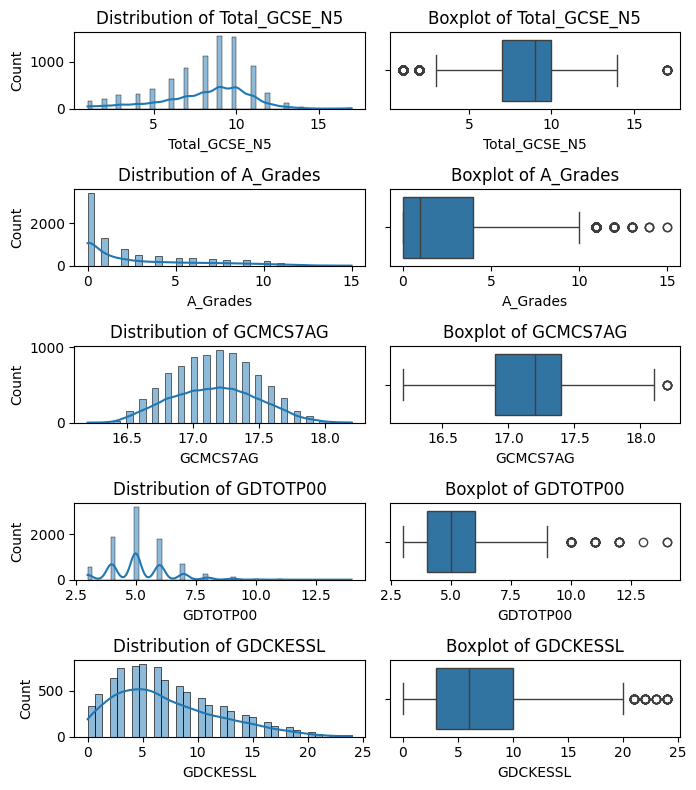

In [ ]:
# Visualisation and Outliers Detection
# Adjust figure size
num_cols = len(numerical_cols)
plt.figure(figsize=(7, 8)) # Adjusted figure height

for i, column in enumerate(numerical_cols): # Use enumerate to get index and column
    plt.subplot(num_cols, 2, i * 2 + 1) # Use num_cols for rows and i for indexing
    sns.histplot(cleaned_data[column], kde=True)
    plt.title(f'Distribution of {column}')

    plt.subplot(num_cols, 2, i * 2 + 2) # Use num_cols for rows and i for indexing
    sns.boxplot(x=cleaned_data[column])
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

4.   **Correlation Matrix (Heatmap)**




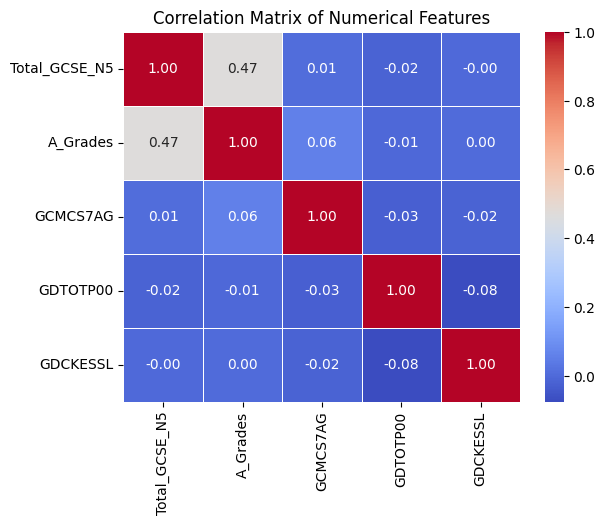

In [ ]:
# Calculate correlation matrix
corr_matrix = cleaned_data[numerical_cols].corr()

# Visualise correlation matrix
plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()




**Visualisation of Categorical variables**











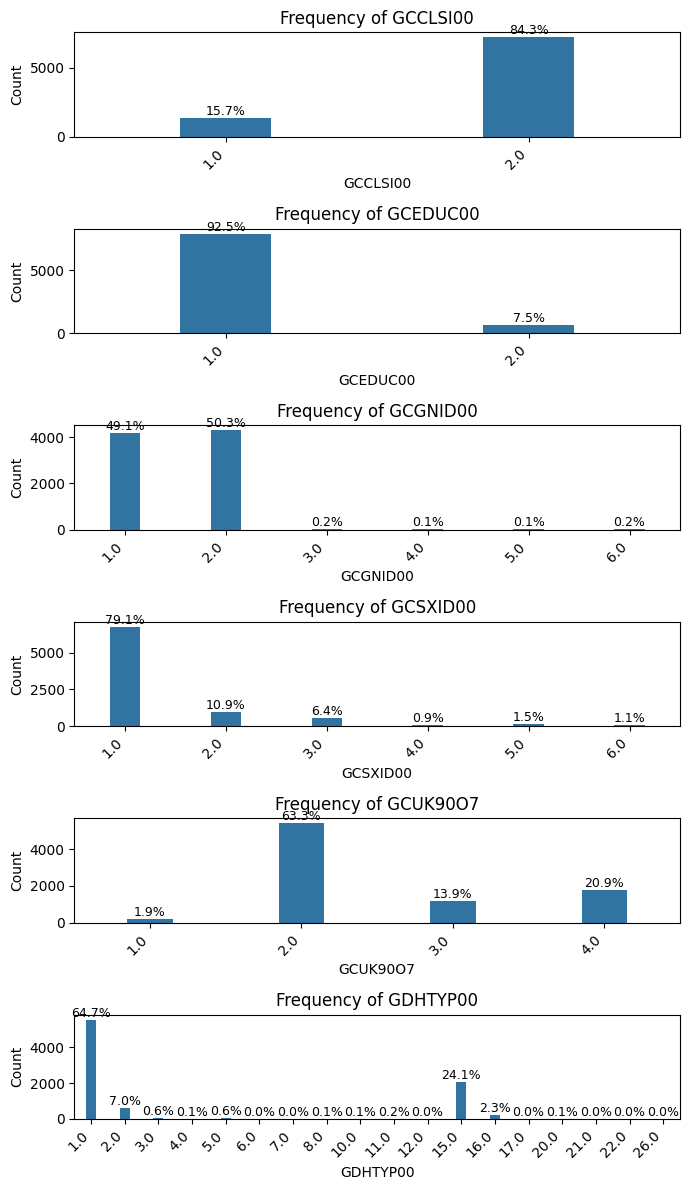

In [ ]:
plt.figure(figsize=(7,12))
for i, column in enumerate(categorical_cols):
    if column == 'Depression': continue # Skip the variable 'Depression'
    plt.subplot(len(categorical_cols), 1, i+1)
    ax = sns.countplot(x=column, data=cleaned_data, width=0.3)
    # Add percentage labels above bars
    for p in ax.patches:
       height = p.get_height()
       percentage = (height / len(cleaned_data[column])) * 100
       ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9)
       plt.title(f'Frequency of {column}')
       plt.xticks(rotation=45, ha='right')
       plt.ylabel('Count')
       plt.tight_layout()
plt.show()

**Variable 'Depression' Engineering**



---





We will use the KESSLER K6 (GDCKESSL) for feature engineering of the target Depression







In [ ]:
#### FEATURE ENGINEERING OF THE TARGET VARIABLE "Depression"

# Create a binary Depression : 1 = Depressed (GDCKESSL >= 13), 0 = Non-Depressed (GDCKESSL < 13)
cleaned_data["Depression"] = np.where(cleaned_data["GDCKESSL"] >= 13, 1, 0)

# Drop the variable GDCKESSL
cm_derived.drop(columns="GDCKESSL", inplace=True)
# Update numerical_cols and categorical_cols
numerical_cols.remove("GDCKESSL")
categorical_cols = categorical_cols.tolist()
categorical_cols.append("Depression")

/tmp/ipython-input-3880886819.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Depression', data=cleaned_data, palette=colours)


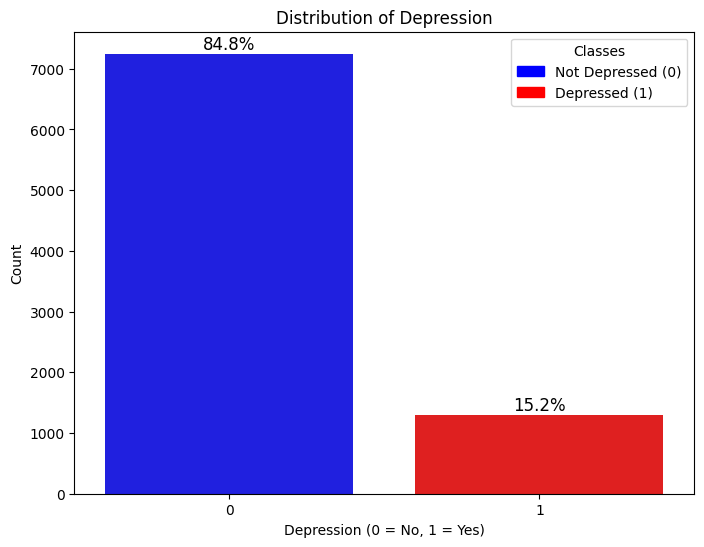

In [ ]:
# Visualisation of the target variable Depression
plt.figure(figsize=(8, 6))
# Custom colours for the 2 bars
colours = ['blue', 'red']   # Blue for 0, Orange for 1

ax = sns.countplot(x='Depression', data=cleaned_data, palette=colours)
# Add percentage labels
total = len(cleaned_data)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom', fontsize=12)
plt.title("Distribution of Depression")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Count")
# ---- Add Legend ----
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colours[0]),
    plt.Rectangle((0, 0), 1, 1, color=colours[1])
]
plt.legend(handles, ["Not Depressed (0)", "Depressed (1)"], title="Classes")
plt.show()

Our Dataset is imbalance. We will make use of SMOTE for balancing during ours models building pipeline.

**Distribution of Variables against the target variable 'Depression'**

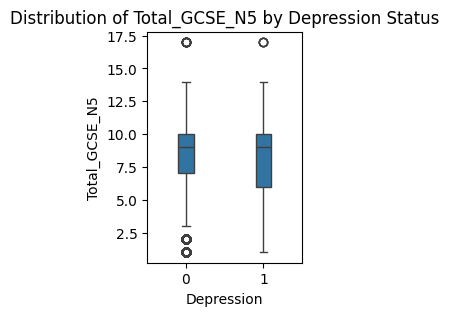

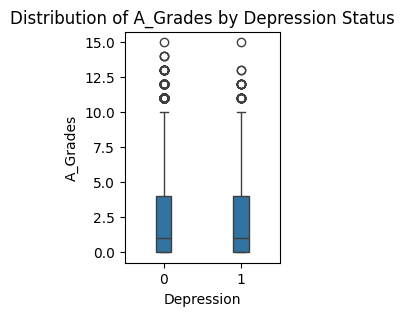

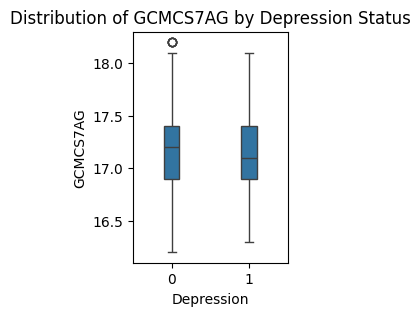

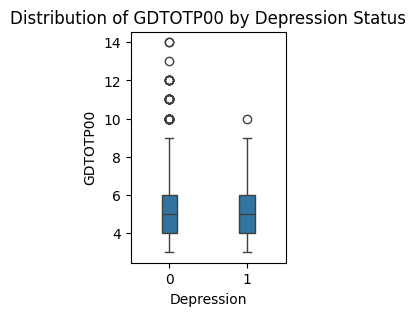

In [ ]:
# Numerical variables vs 'Depression'

for var in numerical_cols:
        plt.figure(figsize=(2,3))
        sns.boxplot(x='Depression', y=var, data=cleaned_data, width=0.2)
        plt.title(f"Distribution of {var} by Depression Status")
        plt.xlabel("Depression")
        plt.ylabel(var)
        plt.show()

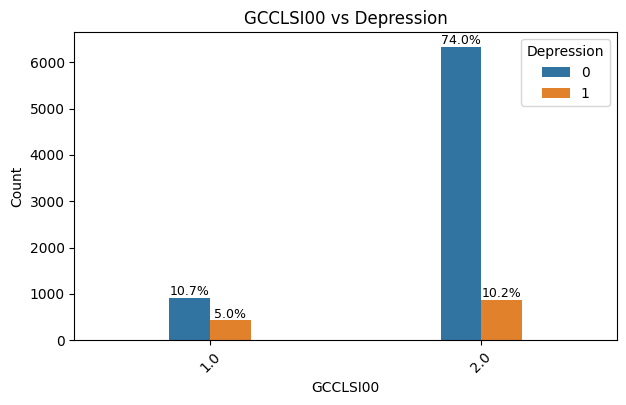

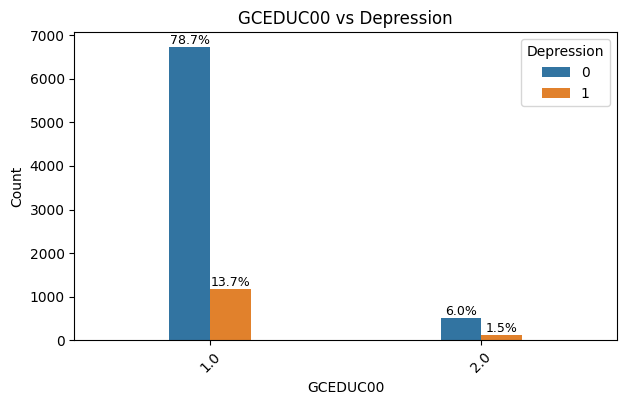

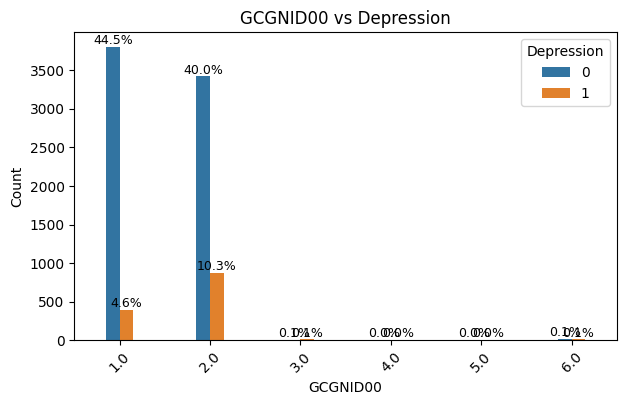

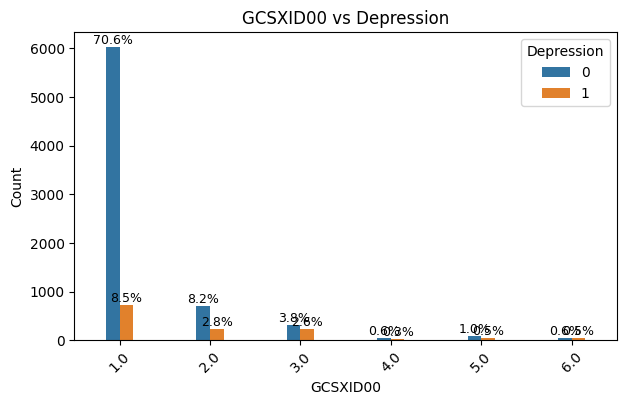

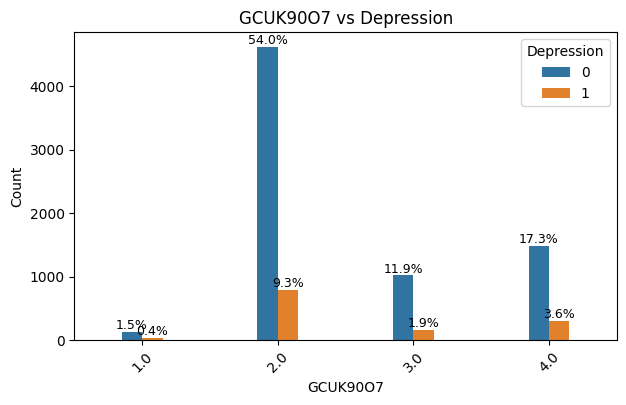

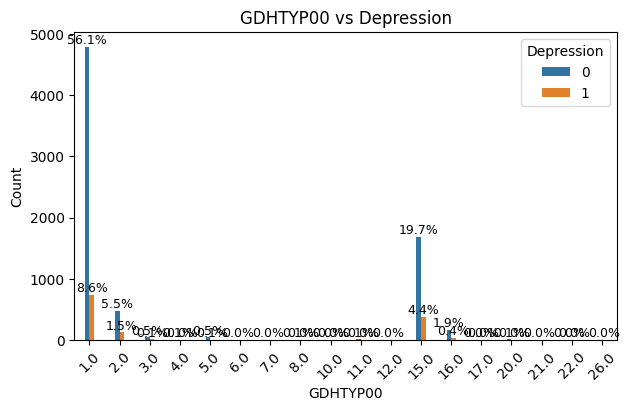

In [ ]:
# Categorical variables

for var in categorical_cols:
    if var != 'Depression':
        plt.figure(figsize=(7,4))
        ax = sns.countplot(x=var, hue='Depression', dodge=True, width=0.3, data=cleaned_data)

        # --- Add percentage labels on each bar ---
        total_counts = cleaned_data['Depression'].value_counts(normalize=True) * 100

        for p in ax.patches:
            height = p.get_height()
            if height == 0:
              continue
            total = len(cleaned_data)
            percent = height / total * 100
            ax.annotate(f'{percent:.1f}%', (p.get_x() + p.get_width()/2., height),
                        ha='center', va='bottom', fontsize=9)
        plt.title(f"{var} vs Depression")
        plt.xlabel(var)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

**Feature Significance vs Depression**

In [ ]:
from scipy.stats import chi2_contingency, f_oneway

y = "Depression"
results = []  # <--- store p-values here
results_num = []
results_cat = []

In [ ]:
# Chi Square for Cat variables
signif_cat_cols = []
for var in categorical_cols:
    if var != y:
        df = cleaned_data[[var, y]].dropna()
        if df[y].nunique() < 2 or df[var].nunique() < 2:
            continue

        contingency = pd.crosstab(df[var], df[y])
        chi2, p, dof, expected = chi2_contingency(contingency)
        if p < 0.05:
            results_cat.append([var, p, "Categorical"])
            signif_cat_cols.append(var)
print('\n Chi Square of Categorical variables')
for var, p, string in results_cat:
    print(f"{var:<20}  p-value = {p:.6f}  {'SIGNIFICANT ' if p < 0.05 else 'NO'}")


 Chi Square of Categorical variables
GCCLSI00              p-value = 0.000000  SIGNIFICANT 
GCEDUC00              p-value = 0.001190  SIGNIFICANT 
GCGNID00              p-value = 0.000000  SIGNIFICANT 
GCSXID00              p-value = 0.000000  SIGNIFICANT 
GCUK90O7              p-value = 0.004371  SIGNIFICANT 
GDHTYP00              p-value = 0.000000  SIGNIFICANT 


In [ ]:
# One-Way ANOVA for num variables
signif_num_cols =[]
for var in numerical_cols:
    if var != y:
        df = cleaned_data[[var, y]].dropna()
        groups = [g[var].values for _, g in df.groupby(y, observed=False)]
        if len(groups) < 2 or any(len(g) < 2 for g in groups):
            continue

        F, p = f_oneway(*groups)
        if p < 0.05:
          results_num.append([var, p, "Numeric"])
          signif_num_cols.append(var)
print('\n One-Way ANOVA of Numerical variables')
for var, p, string in results_num:
    print(f"{var:<20}  p-value = {p:.6f}  {'SIGNIFICANT ' if p < 0.05 else 'NO'}")




 One-Way ANOVA of Numerical variables
Total_GCSE_N5         p-value = 0.023656  SIGNIFICANT 
A_Grades              p-value = 0.010334  SIGNIFICANT 
GCMCS7AG              p-value = 0.024014  SIGNIFICANT 
GDTOTP00              p-value = 0.000010  SIGNIFICANT 


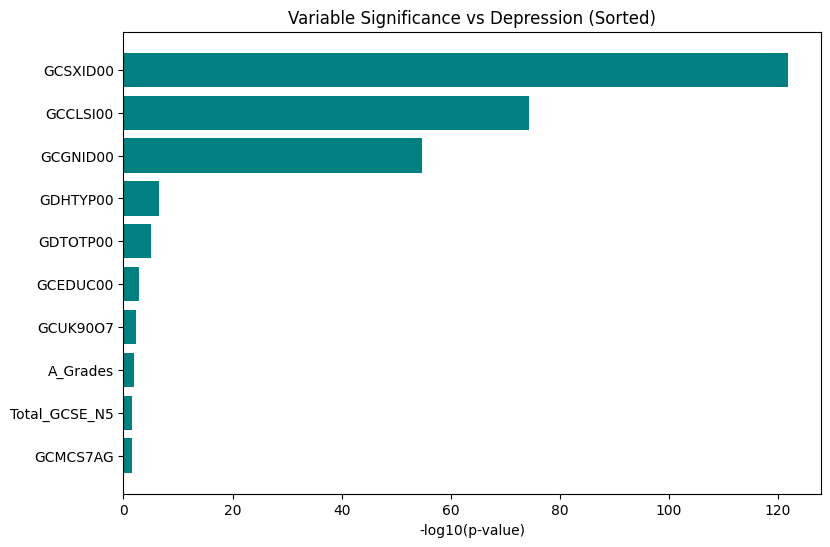

['GCCLSI00', 'GCEDUC00', 'GCGNID00', 'GCSXID00', 'GCUK90O7', 'GDHTYP00'] ['Total_GCSE_N5', 'A_Grades', 'GCMCS7AG', 'GDTOTP00']


In [ ]:
# Convert to DataFrame
results = results_cat + results_num
sig_df = pd.DataFrame(results, columns=["Variable", "p-value", "Type"])
sig_df.sort_values("p-value", inplace=True, ascending=False)
sig_df

# Convert p-value into -log10 scale for better visualization
sig_df["Significance"] = -np.log10(sig_df["p-value"])

# Plotting of Significant variables vs Depression
plt.figure(figsize=(9,6))
bars = plt.barh(sig_df["Variable"], sig_df["Significance"], color="teal")
plt.xlabel("-log10(p-value)")
plt.title("Variable Significance vs Depression (Sorted)")
plt.show()
print(signif_cat_cols, signif_num_cols)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded_array = encoder.fit_transform(cleaned_data[signif_cat_cols])
# Build encoded dataframe
encoded_cat_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(signif_cat_cols),
    index=cleaned_data.index
)
# Combine numeric + encoded categorical + target
encoded_data = pd.concat([cleaned_data[signif_num_cols], encoded_cat_df, cleaned_data["Depression"]], axis=1)

print(encoded_data.head())


   Total_GCSE_N5  A_Grades  GCMCS7AG  GDTOTP00  GCCLSI00_2.0  GCEDUC00_2.0  \
0           11.0        11      17.3         4           1.0           0.0   
1           11.0         5      17.6         5           1.0           0.0   
2            3.0         3      17.2         6           0.0           0.0   
3            8.0         4      17.4         6           1.0           0.0   
4           11.0         7      16.7         5           1.0           0.0   

   GCGNID00_2.0  GCGNID00_3.0  GCGNID00_4.0  GCGNID00_5.0  ...  GDHTYP00_11.0  \
0           0.0           0.0           0.0           0.0  ...            0.0   
1           0.0           0.0           0.0           0.0  ...            0.0   
2           1.0           0.0           0.0           0.0  ...            0.0   
3           0.0           0.0           0.0           0.0  ...            0.0   
4           1.0           0.0           0.0           0.0  ...            0.0   

   GDHTYP00_12.0  GDHTYP00_15.0  GDHTYP00_16

**MODEL BUILDING AND EVALUATION, NO TUNING**

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00



Scaler     | Model           | F1 (W)   | F1 (Depr) | AUC      | ACC     
------------------------------------------------------------------------------------------
None       | CatBoost        | 0.7701   | 0.3764    | 0.7041   | 0.7462 
None       | RandomForest    | 0.8011   | 0.2430    | 0.6559   | 0.8251
None       | XGBoost         | 0.8095   | 0.2169    | 0.6758   | 0.8480
Robust     | KNN             | 0.7480   | 0.3181    | 0.6758   | 0.7216
Robust     | SVC             | 0.7826   | 0.2917    | 0.6758   | 0.7813

========== GENERATING PLOTS ==========


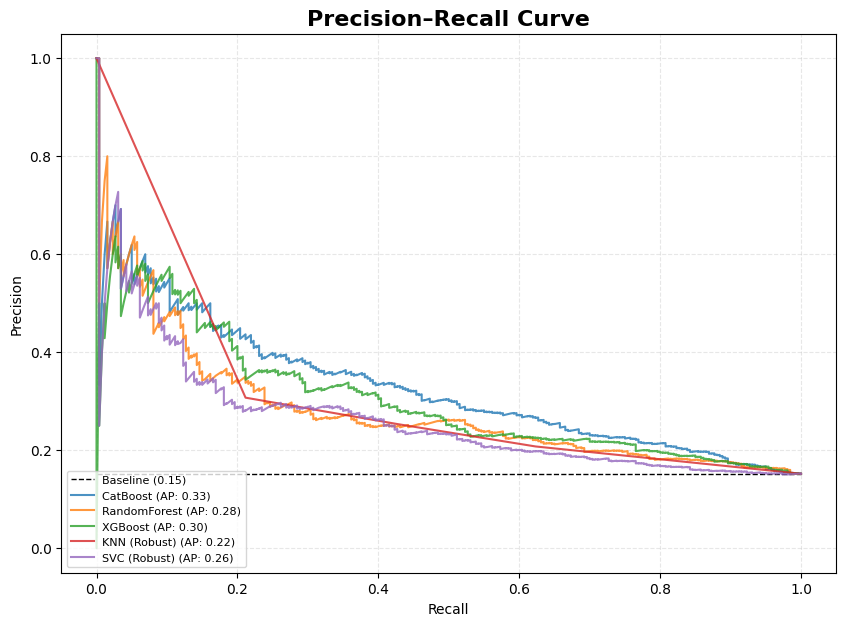

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score, precision_score, recall_score)


# =========================================================================
# NOTE: This script assumes 'cleaned_data', 'encoded_data', 'signif_num_cols',
# and 'signif_cat_cols' are defined before running.
# =========================================================================

# =========================================================================
# 1. DATA SETUP
# =========================================================================
# Placeholder check to ensure code runs in isolation if variables aren't present
if 'cleaned_data' not in locals():
    print("WARNING: 'cleaned_data' and 'encoded_data' not found. Please load your datasets first.")
else:
    target = "Depression"

    # --- Raw Data (For CatBoost) ---
    X_cat = cleaned_data[signif_cat_cols + signif_num_cols].copy()
    y_cat = cleaned_data[target].astype(int)
    for col in signif_cat_cols:
        X_cat[col] = X_cat[col].astype(str)

    X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
        X_cat, y_cat, test_size=0.2, stratify=y_cat, random_state=42
    )

    # --- Encoded Data (For RF, XGB, Ada, KNN, SVC) ---
    X_enc = encoded_data.drop(columns=[target])
    y_enc = encoded_data[target].astype(int)

    X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
        X_enc, y_enc, test_size=0.2, stratify=y_enc, random_state=42
    )

    # Shared Settings
    cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    # =========================================================================
    # 2. MODEL TRAINING LOOPS
    # =========================================================================
    # Header Titles
    print(f"\n{'Scaler':<10} | {'Model':<15} | {'F1 (W)':<8} | {'F1 (Depr)':<9} | {'AUC':<8} | {'ACC':<8}")
    print("-" * 90)

    # -------------------------------------------------
    #  CATBOOST (Raw Data, Internal Balance, No Scale)
    # -------------------------------------------------

    # Use raw training data directly
    cb = CatBoostClassifier(verbose=0, random_state=42, scale_pos_weight=5, cat_features=signif_cat_cols)
    grid_cb = GridSearchCV(cb, {'iterations': [100,200], 'depth': [4, 6], 'learning_rate': [0.01,0.03]}, scoring='f1', cv=cv_splitter, n_jobs=-1)

    grid_cb.fit(X_train_cat, y_train_cat)
    best_cb = grid_cb.best_estimator_

    # Evaluate
    y_pred = best_cb.predict(X_test_cat)

    # Calculate both Weighted and Minority Class F1
    f1_w = f1_score(y_test_cat, y_pred, average='weighted')
    f1_min = f1_score(y_test_cat, y_pred, pos_label=1)

    acc = accuracy_score(y_test_cat, y_pred)
    prec = precision_score(y_test_cat, y_pred)
    rec = recall_score(y_test_cat, y_pred)
    auc_score = roc_auc_score(y_test_cat, best_cb.predict_proba(X_test_cat)[:, 1])

    results.append({
        "Model": "CatBoost", "Scaler": "None",
        "F1_W": f1_w, "F1_Min": f1_min,
        "AUC": auc_score, "ACC": acc, "Precision": prec, "Recall": rec,
        "Model_Object": best_cb, "Test_Type": "Raw"
    })

    print(f"{'None':<10} | {'CatBoost':<15} | {f1_w:.4f}   | {f1_min:.4f}    | {auc_score:.4f}   | {acc:.4f} ")

    # -------------------------------------------------
    # PREPARE SHARED DATA FOR GROUPS 2 & 3
    # -------------------------------------------------
    # Apply SMOTE directly to encoded training data
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train_enc, y_train_enc)

    # -------------------------------------------------
    # TREE MODELS (Encoded, No Scale)
    # -------------------------------------------------
    # Handling imbalance data in the model param +SMOTE
    imbalance_ratio = y_res.value_counts()[0] / y_res.value_counts()[1]
    tree_models = { "RandomForest": (RandomForestClassifier(
                       class_weight='balanced',
                        random_state=42),
                            {'n_estimators': [100, 200], 'max_depth': [10, 20]}
                                     ),
                     "XGBoost": (XGBClassifier(
                         scale_pos_weight=imbalance_ratio,  # Add this parameter
                         eval_metric="logloss",
                         random_state=42),
                          {'n_estimators': [100, 200], 'max_depth': [3, 5]}
                                 )
                     }

    for name, (model, params) in tree_models.items():

        pipe = Pipeline([("model", model)])
        grid = GridSearchCV(pipe, {f"model__{k}": v for k, v in params.items()}, scoring='f1', cv=cv_splitter, n_jobs=-1)
        grid.fit(X_res, y_res)

        best_mod = grid.best_estimator_

        y_pred = best_mod.predict(X_test_enc)

        f1_w = f1_score(y_test_enc, y_pred, average='weighted')
        f1_min = f1_score(y_test_enc, y_pred, pos_label=1)

        acc = accuracy_score(y_test_enc, y_pred)
        prec = precision_score(y_test_enc, y_pred)
        rec = recall_score(y_test_enc, y_pred)
        auc_score = roc_auc_score(y_test_enc, best_mod.predict_proba(X_test_enc)[:, 1])

        results.append({
            "Model": name, "Scaler": "None",
            "F1_W": f1_w, "F1_Min": f1_min,
            "AUC": auc_score, "ACC": acc, "Precision": prec, "Recall": rec,
            "Model_Object": best_mod, "Test_Type": "Encoded"
        })
        print(f"{'None':<10} | {name:<15} | {f1_w:.4f}   | {f1_min:.4f}    | {auc_score:.4f}   | {acc:.4f}")

    # -------------------------------------------------
    # DISTANCE MODELS (Encoded, ONLY ROBUST SCALER)
    # -------------------------------------------------
    scale_name = "Robust"
    scaler_obj = RobustScaler()

    dist_models = {
        "KNN": (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
        "SVC": (SVC(probability=True, class_weight='balanced', random_state=42), {'C': [0.1, 1, 10], 'kernel': ['rbf']})
    }

    for model_name, (model, params) in dist_models.items():

        # Pipeline: Scaler -> Model
        pipe = Pipeline([("scaler", scaler_obj), ("model", model)])
        grid = GridSearchCV(pipe, {f"model__{k}": v for k, v in params.items()}, scoring='f1', cv=cv_splitter, n_jobs=-1)

        grid.fit(X_res, y_res)

        best_mod = grid.best_estimator_
        y_pred = best_mod.predict(X_test_enc)

        f1_w = f1_score(y_test_enc, y_pred, average='weighted')
        f1_min = f1_score(y_test_enc, y_pred, pos_label=1)

        acc = accuracy_score(y_test_enc, y_pred)
        prec = precision_score(y_test_enc, y_pred)
        rec = recall_score(y_test_enc, y_pred)


        results.append({
            "Model": model_name, "Scaler": scale_name,
            "F1_W": f1_w, "F1_Min": f1_min,
            "AUC": auc_score, "ACC": acc, "Precision": prec, "Recall": rec,
            "Model_Object": best_mod, "Test_Type": "Encoded"
        })
        print(f"{scale_name:<10} | {model_name:<15} | {f1_w:.4f}   | {f1_min:.4f}    | {auc_score:.4f}   | {acc:.4f}")

    # =========================================================================
    # PLOTTING RESULTS
    # =========================================================================
    print("\n========== GENERATING PLOTS ==========")

    # Create a DataFrame for easy plotting
    df_results = pd.DataFrame(results)

    # Create a label for the plot that includes scaler info if present
    df_results['Model_Label'] = df_results.apply(
        lambda x: x['Model'] if x['Scaler'] == 'None' else f"{x['Model']} ({x['Scaler']})",
        axis=1
    )

plt.figure(figsize=(10, 7))
plt.title("Precision–Recall Curve", fontsize=16, fontweight="bold")

baseline = y_test_enc.mean()
plt.plot([0, 1], [baseline, baseline], 'k--', lw=1, label=f'Baseline ({baseline:.2f})')

for row in results:
    model_name = row['Model']
    scaler_name = row['Scaler']
    model_obj = row['Model_Object']
    test_type = row['Test_Type']

    # Label
    label_name = model_name if scaler_name == "None" else f"{model_name} ({scaler_name})"

    # Pick correct test data
    if test_type == "Raw":
        X_curr, y_curr = X_test_cat, y_test_cat
    else:
        X_curr, y_curr = X_test_enc, y_test_enc

    # PR curve
    if hasattr(model_obj, "predict_proba"):
        y_proba = model_obj.predict_proba(X_curr)[:, 1]
        prec, rec, _ = precision_recall_curve(y_curr, y_proba)
        ap_val = average_precision_score(y_curr, y_proba)

        plt.plot(rec, prec, lw=1.5, alpha=0.8,
                 label=f"{label_name} (AP: {ap_val:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left", fontsize=8, ncol=1)
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()


**FEATURE IMPORTANCE RANKING: SHAP GLOBAL PLOT FOR TREES MODELS**

Generating Feature Importance Bar and Beeswarm Plots...
--- CatBoost: Calculating SHAP (TreeExplainer) ---


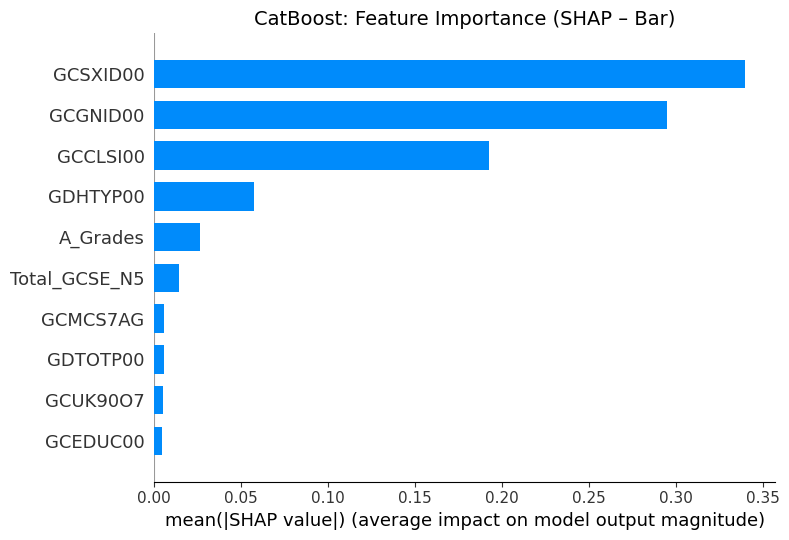

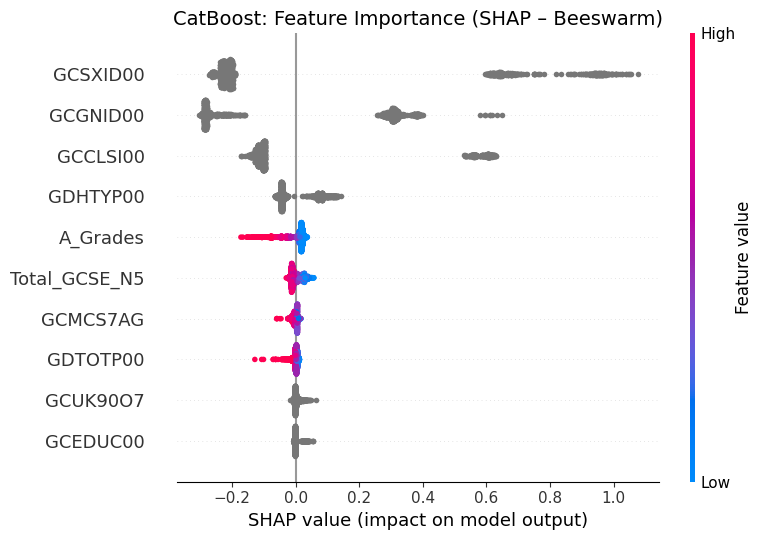

Plotting Dependence Plots for ALL Categorical variables...


<Figure size 1000x600 with 0 Axes>

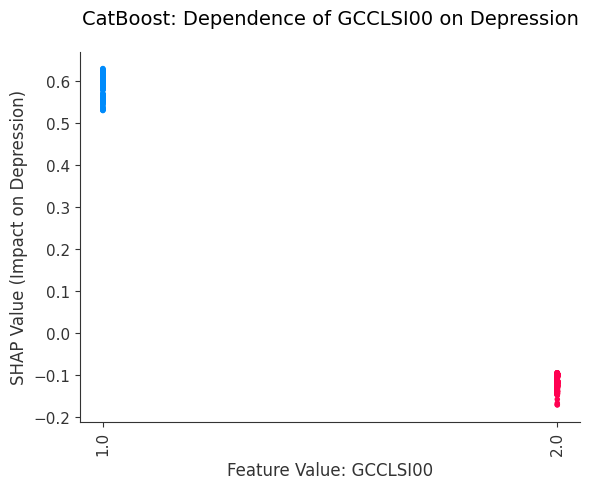

<Figure size 1000x600 with 0 Axes>

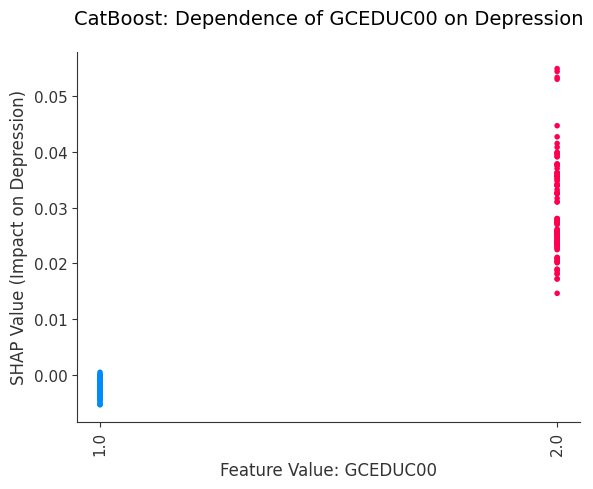

<Figure size 1000x600 with 0 Axes>

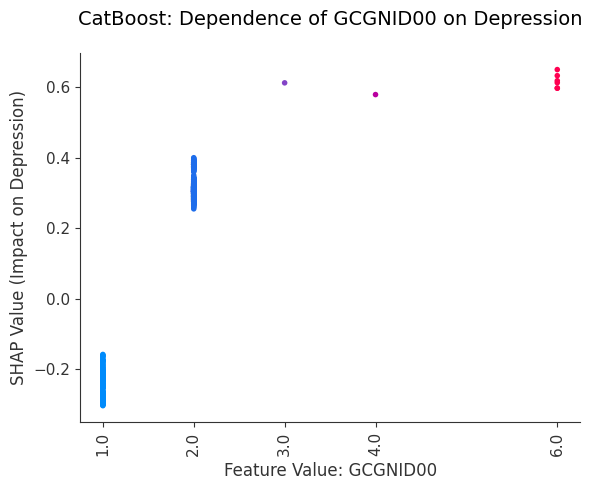

<Figure size 1000x600 with 0 Axes>

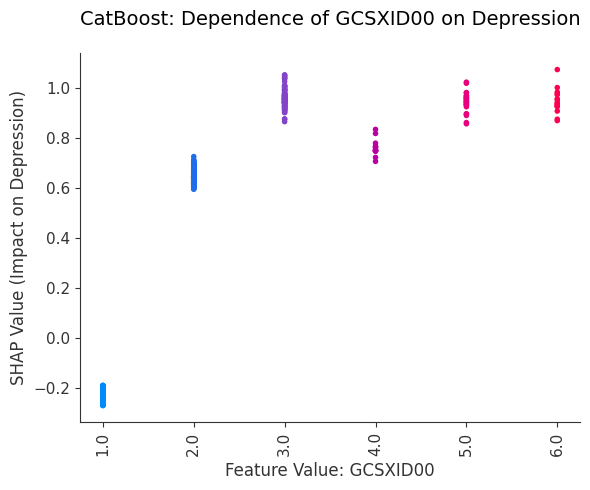

<Figure size 1000x600 with 0 Axes>

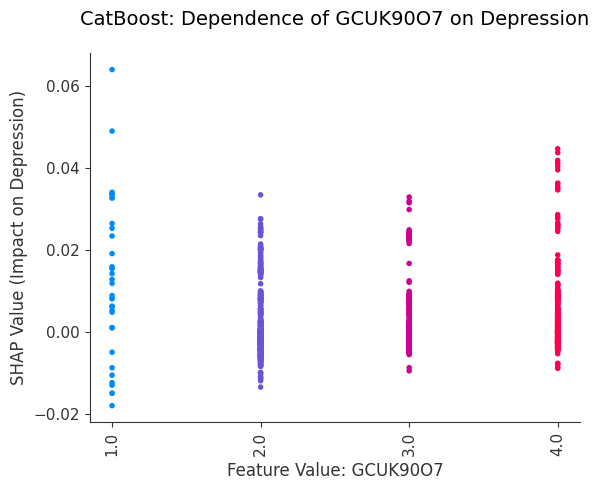

<Figure size 1000x600 with 0 Axes>

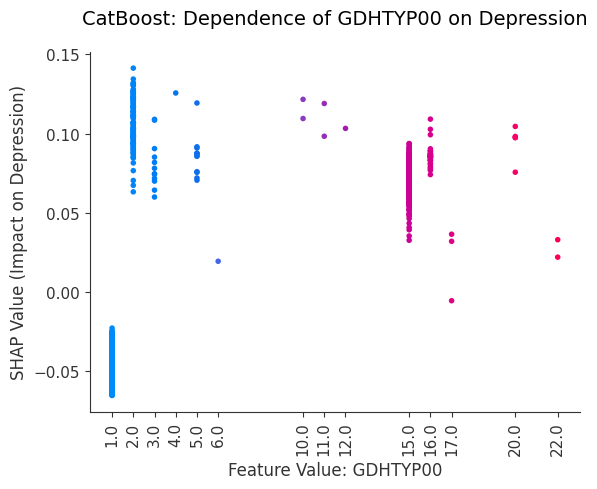

--- RandomForest: Calculating SHAP (TreeExplainer) ---


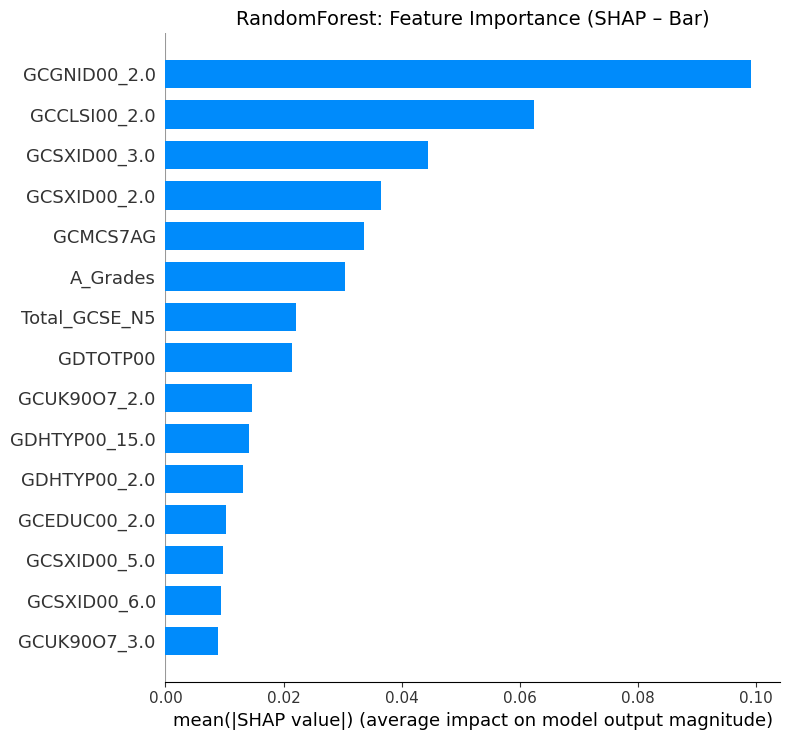

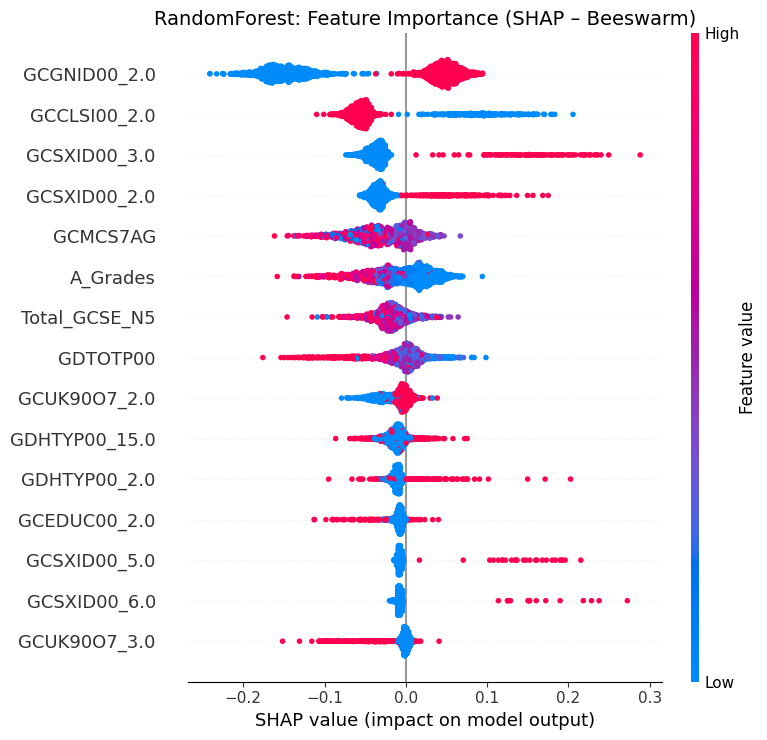

--- XGBoost: Calculating SHAP (TreeExplainer) ---


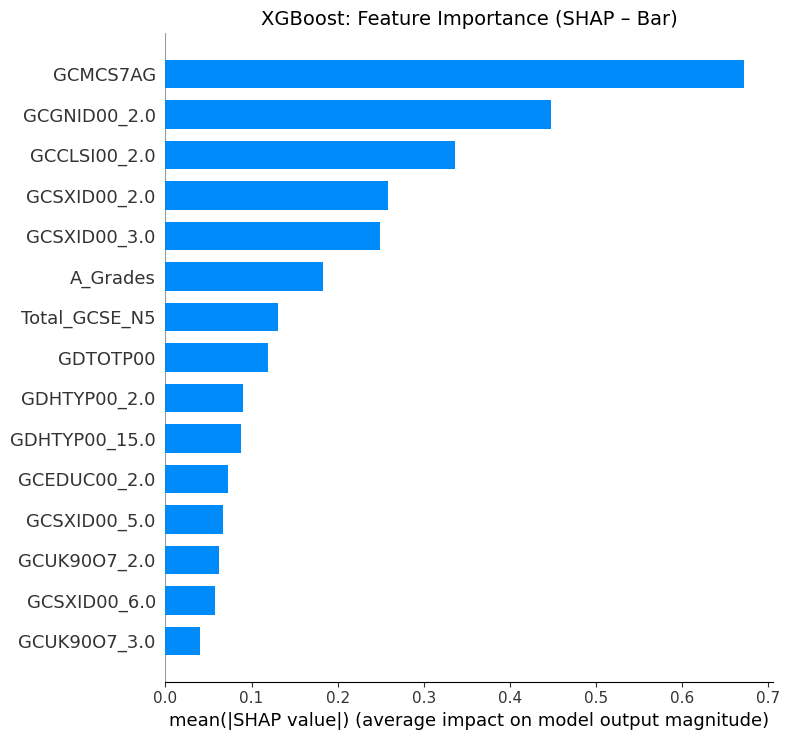

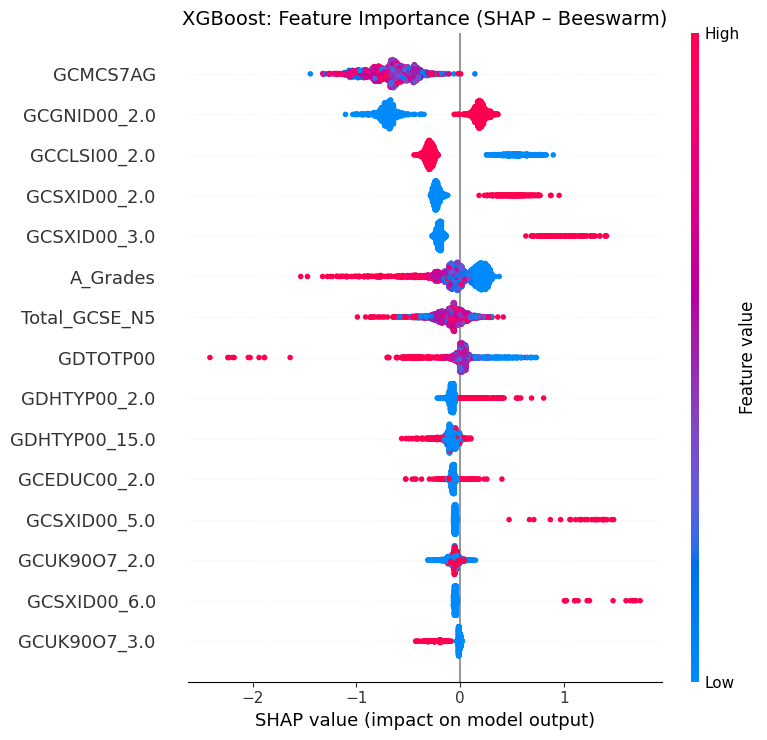

In [ ]:
import shap
from sklearn.inspection import permutation_importance

# =========================================================================
# FEATURE IMPORTANCE RANKING (SHAP: BAR + BEESWARM)
# =========================================================================

print("Generating Feature Importance Bar and Beeswarm Plots...")

for row in results:
    model_name = row['Model']
    model_obj = row['Model_Object']

    # Determine which test set to use (CatBoost used X_test_cat, others X_test_enc)
    if model_name == "CatBoost":
        X_test_current = X_test_cat
        y_test_current = y_test_cat
    else:
        X_test_current = X_test_enc
        y_test_current = y_test_enc

    # ---------------------------------------------------------
    # GROUP 1: SHAP with TreeExplainer (CatBoost, RandomForest, XGBoost)
    # ---------------------------------------------------------
    if model_name in ["CatBoost", "RandomForest", "XGBoost"]:
        print(f"--- {model_name}: Calculating SHAP (TreeExplainer) ---")

        # Extract the underlying classifier if model_obj is a Pipeline
        if isinstance(model_obj, Pipeline) and 'model' in model_obj.named_steps:
            classifier = model_obj.named_steps['model']
        else:
            classifier = model_obj

        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer.shap_values(X_test_current)

        # Handle SHAP output for binary classification (take values for the positive class)
        if isinstance(shap_values, list):
            vals = shap_values[1]
        elif shap_values.ndim == 3:
            vals = shap_values[:, :, 1]
        else:
            vals = shap_values

        # ---------- BAR PLOT ----------
        plt.figure(figsize=(10, 6))
        shap.summary_plot(vals, X_test_current,
                          plot_type="bar",
                          show=False,
                          max_display=15)
        plt.title(f"{model_name}: Feature Importance (SHAP – Bar)", fontsize=14)
        plt.tight_layout()
        plt.show()
        plt.close()

        # ---------- BEESWARM PLOT ----------
        plt.figure(figsize=(10, 6))
        shap.summary_plot(vals, X_test_current,
                          show=False,
                          max_display=15)
        plt.title(f"{model_name}: Feature Importance (SHAP – Beeswarm)", fontsize=14)
        plt.tight_layout()
        plt.show()
        plt.close()

        # ----------- DEPENDENCE PLOT (CatBoost only) ------------
        if model_name == "CatBoost":
            print("Plotting Dependence Plots for ALL Categorical variables...")
            # Corrected loop condition
            for feat in [f for f in X_test_current.columns if f in signif_cat_cols]:
                plt.figure(figsize=(10, 6))
                # Generate standard dependence plot
                # interaction_index=feat ensures points are colored by the feature value itself
                shap.dependence_plot(
                    feat,
                    vals,
                    X_test_current,
                    display_features=X_test_current,
                    show=False,
                    interaction_index=feat
                )

                # Add clear labels and legend
                plt.xlabel(f"Feature Value: {feat}", fontsize=12)
                plt.ylabel("SHAP Value (Impact on Depression)", fontsize=12)
                plt.title(f"CatBoost: Dependence of {feat} on Depression", fontsize=14, pad=20)
                plt.tight_layout()
                plt.show()
                plt.close()



**FEATURES IMPORTANCE RANKING: PERMUTATION FOR KNN AND SVC**

Starting Permutation Feature Importance Analysis for ALL Models...
Calculating for KNN... Done.
Calculating for SVC... Done.


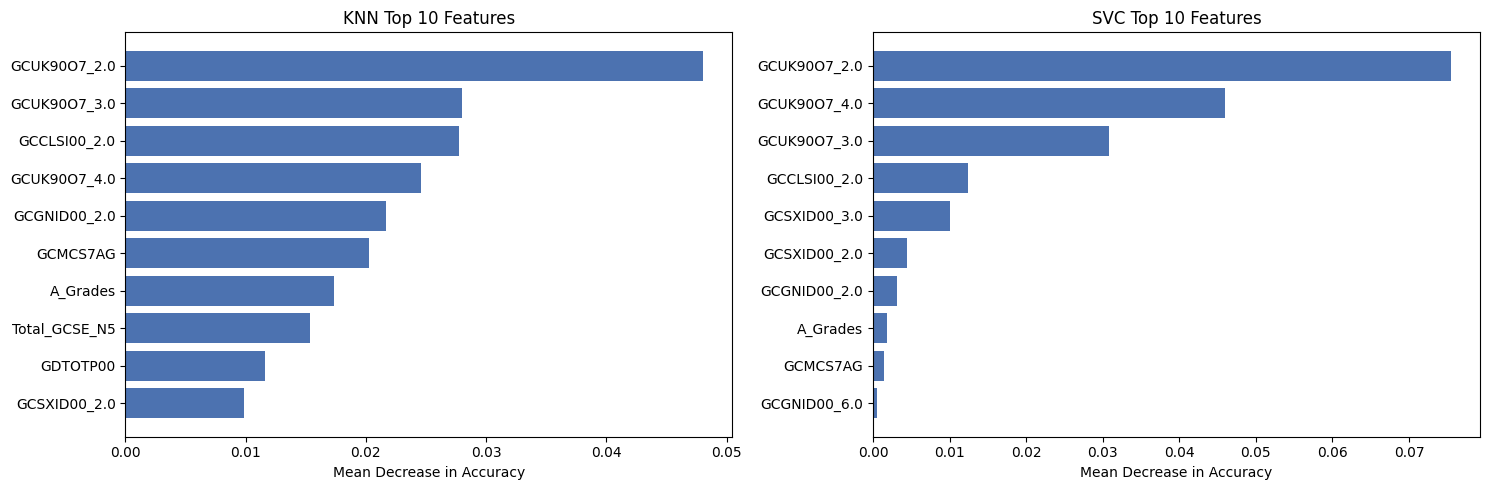


--- KNN Top 5 Predictors ---
     Feature  Importance
GCUK90O7_2.0    0.048070
GCUK90O7_3.0    0.027953
GCCLSI00_2.0    0.027778
GCUK90O7_4.0    0.024620
GCGNID00_2.0    0.021696

--- SVC Top 5 Predictors ---
     Feature  Importance
GCUK90O7_2.0    0.075497
GCUK90O7_4.0    0.045906
GCUK90O7_3.0    0.030760
GCCLSI00_2.0    0.012339
GCSXID00_3.0    0.010000


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================================
# FEATURE IMPORTANCE RANKING (PERMUTATION METHOD)
# =========================================================================

importance_summary = {}
print("Starting Permutation Feature Importance Analysis for ALL Models...")

for row in results:
    model_name = row['Model']
    model_obj = row['Model_Object']
    if model_name in ['KNN','SVC']:
      print(f"Calculating for {model_name}...", end=" ")
      X_curr = X_test_enc
      y_test = y_test_enc

      #  Compute Permutation Importance
      # n_repeats=10 means we shuffle each feature 10 times to get a stable average
      perm_result = permutation_importance(
          model_obj, X_curr, y_test, n_repeats=10, random_state=42, n_jobs=-1
          )
      # Extract & Store Results
      importances = perm_result.importances_mean
      feature_names = X_curr.columns

      df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
      # Sort by importance (highest first)
      df_imp = df_imp.sort_values(by='Importance', ascending=False)

      importance_summary[model_name] = df_imp
      print("Done.")

# =========================================================================
# VISUALISATION
# =========================================================================

# Determine layout for subplots
num_models = len(importance_summary)
if num_models > 0:
    cols = 2
    rows = (num_models + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

    # Flatten axes array for easy iteration
    if num_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (model_name, df) in enumerate(importance_summary.items()):
        ax = axes[i]

        # Get Top 10 Features for plotting
        # We sort ascending here so the horizontal bar chart shows best at top
        top_df = df.head(10).sort_values(by="Importance", ascending=True)

        ax.barh(top_df['Feature'], top_df['Importance'], color='#4c72b0')
        ax.set_title(f"{model_name} Top 10 Features")
        ax.set_xlabel("Mean Decrease in Accuracy")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# =========================================================================
# TEXT SUMMARY (TOP 5)
# =========================================================================
for model_name, df in importance_summary.items():
    print(f"\n--- {model_name} Top 5 Predictors ---")
    print(df.head(5).to_string(index=False))

**SHAP FAIRNESS ANALYSIS** Case of CatBoost


========== CATBOOST SHAP WATERFALL (COUNTERFACTUAL ON GCGNID00) ==========
Original GCGNID00 value: 1.0


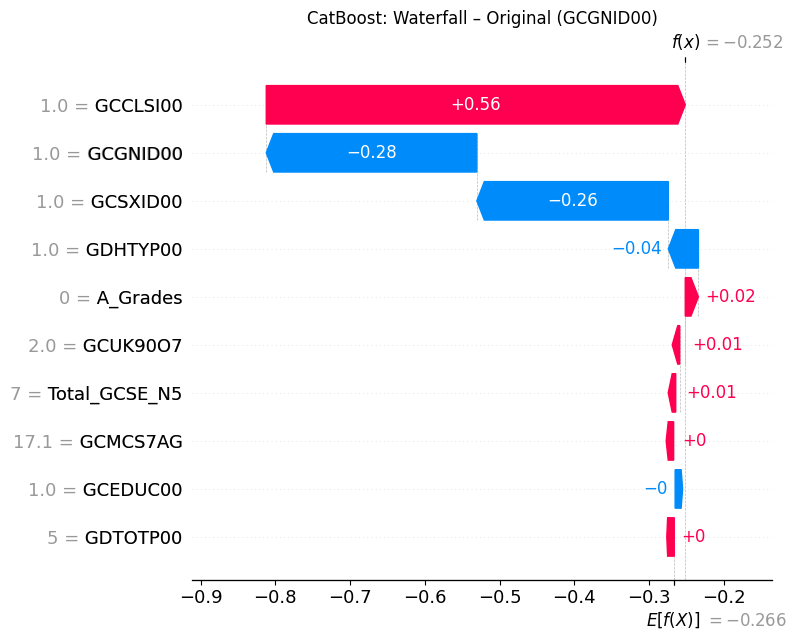

Counterfactual GCGNID00 value: 2


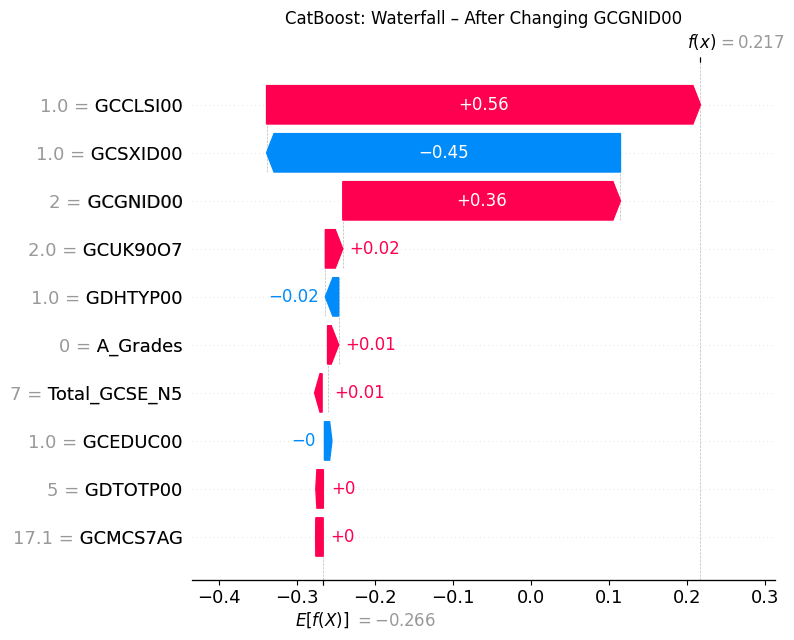

In [ ]:
 # --- D. Waterfall Plot (First Observation: Before & After Changing GCGNID00) ---
print("\n========== CATBOOST SHAP WATERFALL (COUNTERFACTUAL ON GCGNID00) ==========")

# --- FIX: Initialize explainer_cb ---
# Find the CatBoost model object from the results list
catboost_model_entry = next(item for item in results if item["Model"] == "CatBoost")
best_cb = catboost_model_entry["Model_Object"]
explainer_cb = shap.TreeExplainer(best_cb)
# ------------------------------------

# Index of the instance we want to inspect
idx = 5

# 1. Get original row for the first test instance
orig_row = X_test_cat.iloc[[idx]].copy()   # keep as DataFrame
print("Original GCGNID00 value:", orig_row["GCGNID00"].iloc[0])

# 2. SHAP explanation for the original instance
explanation_orig = explainer_cb(orig_row)  # returns a shap.Explanation object

# 3. Plot waterfall for the original instance
plt.figure()
shap.plots.waterfall(explanation_orig[0], show=False)
plt.title("CatBoost: Waterfall – Original (GCGNID00)", fontsize=12)
plt.tight_layout()
plt.show()

# 4. Create a counterfactual row by changing GCGNID00
cf_row = orig_row.copy()

# Rule: if 1 -> 2, if 2 -> 1, otherwise set to 1
current_gender = cf_row["GCGNID00"].iloc[0]
if float(current_gender) == 1.0:
    cf_row.loc[:, "GCGNID00"] = 2
elif float(current_gender) == 2.0:
    cf_row.loc[:, "GCGNID00"] = 1
else:
    # if it's 3–6 (other identities), force to 1 just to see the contrast
    cf_row.loc[:, "GCGNID00"] = 1

print("Counterfactual GCGNID00 value:", cf_row["GCGNID00"].iloc[0])

# 5. SHAP explanation for the counterfactual instance
explanation_cf = explainer_cb(cf_row)

# 6. Plot waterfall for the counterfactual instance
plt.figure()
shap.plots.waterfall(explanation_cf[0], show=False)
plt.title("CatBoost: Waterfall – After Changing GCGNID00", fontsize=12)
plt.tight_layout()
plt.show()
